In this notebook, we numerically implement a fast implementation of the Wigner Function through a FFT rewrite

In [1]:
import nifty.nifty.cl as ift
import nifty8 as ift8
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib notebook
from data.style_components.matplotlib_style import *


In [2]:
# Functions

def dt(domainoid):
    return ift.DomainTuple.make(domainoid)

def mirror_negative_frequencies(arr, standard_order:bool, unique_k_lengths=False):
    """
    Takes an array which is a function of fourier lengths and constructs the full array over the negative frequencies,
    assuming a real field. For example:

        nu = [0.  0.5 1.  1.5 2.  2.5]  -> [-2.5 -2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5  2. ]

    and therefore correspondingly

        field = [ 0.1  0.4 -0.2  1.5 -0.5  1.1]  -> [1.1 -0.5 1.5 -0.2 0.4 0.1 0.4 -0.2 1.5 -0.5].

    If standard_order == True, the standard FFT order will be applied, i.e.: arr[0] corresponds to the 0 frequency. Then with ascending index come positive
    frequencies until the Nyquist frequency EXCLUDED, after which the negative frequencies come with their absolute value decreasing with ascending index.

    E.g.: nu = [0.  0.5 1.  1.5 2.  2.5] -> [ 0.   0.5  1.   1.5  2.  -2.5 -2.  -1.5 -1.  -0.5]

    Standard order source: https://numpy.org/doc/stable/reference/routines.fft.html#module-numpy.fft
    Note that this is also very likely what harmonic_space.get_k_length_array() returns (or rather the absolute value of the standard order).

    :param standard_order:  Whether to apply the standard FFT order or not, in which the array will be truly mirrored around k=0.
    :param unique_k_lengths:            Whether the input array represents unique k-lengths. If not, a field is assumed.
    :param arr:             The array to mirror. This array must be reported at unique k-lengths! I.e. from nu=0 to nu=N_nyquist.
    :return:
    """
    if standard_order:
        return np.concatenate([[arr[0]], arr[1:-1], -arr[-1:0:-1]])
    if unique_k_lengths:
        to_the_left = -arr[1:][::-1]
    else:
        if standard_order:
            return
        to_the_left = arr[1:][::-1].conj()
    res = np.append(to_the_left, arr[:-1])
    return res

def get_full_harmonic_field_from_isotropic(fld, standard_order:bool):
    """
    Returns a field living on full harmonic space with mirrored values.
    :param standard_order:  Whether to apply the standard FFT order or not.
    :param fld: A field that is defined over a power space containing only unique values.
    :return:
    """
    p_space = fld.domain
    vals = mirror_negative_frequencies(fld.asnumpy(), standard_order=standard_order)
    return ift.Field(dt(p_space[0]._harmonic_partner), vals)

def periodic_frequency_wrap(freq, N_nyquist):
    """
    Wrap frequencies periodically into the interval [-N_nyquist, N_nyquist).

    Parameters
    ----------
    freq : array_like or float
        The frequency or array of frequencies to be wrapped.
    N_nyquist : float
        The Nyquist frequency defining the upper/lower bounds of the interval.

    Returns
    -------
    wrapped : array_like or float
        The frequency/frequencies mapped into [-N_nyquist, N_nyquist).

    Notes
    -----
    If a frequency lies outside the primary interval, it is mapped back using
    periodicity. For example, if N_nyquist = 250 and frequ = -625:
        - Step 1: shift by N_nyquist -> -625 + 250 = -375
        - Step 2: modulo period (500) -> -375 % 500 = 125
        - Step 3: shift back by N_nyquist -> 125 - 250 = -125

    This ensures all frequencies are within the valid range and suitable for
    interpolation on a regular harmonic grid.
    """
    period = 2*N_nyquist
    return ((freq + N_nyquist) % period) - N_nyquist

def sn_complex_xi(size, scale=1, use_complex=True):
    # standard normal, complex valued xi
    # scale sets the standard deviation! => scale' = sqrt(scale) if you want to set variance by scale
    if use_complex:
        res = 1/2*np.random.randn(size) + 1/2*np.random.randn(size) * 1j
    else:
        res = np.random.randn(size)
    return scale * res

In [3]:

L = 2
N = 200
dx = L/N

N_prime = 2*N+1
dx_prime = L/N_prime

N_prime_prime = 1/2*N
dx_prime_prime = L/N_prime_prime

x = ift.RGSpace(shape=(N,), distances=dx)
x_prime = ift.RGSpace(shape=(N_prime,), distances=dx_prime)
x_prime_prime = ift.RGSpace(shape=(N_prime_prime,), distances=dx_prime_prime)

y = x.get_default_codomain()
y_prime = x_prime.get_default_codomain()
y_prime_prime = x_prime_prime.get_default_codomain()
p = ift.PowerSpace(y)

tmp = y.get_unique_k_lengths()
tmp_prime = y_prime.get_unique_k_lengths()
tmp_prime_prime = y_prime_prime.get_unique_k_lengths()

omega_nyquist = 1/(2*dx)
nu_nyquist = 1/(2*dx_prime)
omega_prime_nyquist = 1/(2*dx_prime_prime)

omega = mirror_negative_frequencies(tmp, unique_k_lengths=True, standard_order=False)
omega_prime = mirror_negative_frequencies(tmp_prime_prime, unique_k_lengths=True, standard_order=False)
nu = mirror_negative_frequencies(tmp_prime, unique_k_lengths=True, standard_order=False)

time = np.linspace(0, L, N)

nu = nu[::2]

print("nyquist frequency in omega :", omega_nyquist)
print("nyquist frequency in denser nu variable :", nu_nyquist)
print("nyquist frequency of coarse omega_prime variable :", omega_prime_nyquist)
# F = ift.FFTOperator(domain=x, target=y)

nyquist frequency in omega : 50.0
nyquist frequency in denser nu variable : 100.25
nyquist frequency of coarse omega_prime variable : 25.0


In [4]:
# tilde_xi_ps = ift.from_random(p)
# tilde_xi = get_full_harmonic_field_from_isotropic(tilde_xi_ps, standard_order=False)

### --- case 1: Spike

omega_star = -49
i_star = np.argmin(np.abs(omega-omega_star))
print("Omega star: ", omega[i_star], " at index ", i_star)
omega_star = omega[i_star]
vals_tmp = np.zeros(N)
vals_tmp[i_star] = 100


### --- case 2: Spike range
# i_star_min = 300
# i_star_max = 600
# print("Omega star range: ", omega[i_star_min], "  -  ", omega[i_star_max])
# vals_tmp = np.zeros(N)
# vals_tmp[i_star_min:i_star_max] = 1e3

## --- case 3: standard normal
# vals_tmp = sn_complex_xi(N, scale=np.sqrt(L))

## --- case 4: padded standard normal
# vals_tmp = sn_complex_xi(int(N/2), scale=np.sqrt(L))
# N_half = len(vals_tmp)
# N_full = N
# n_pad = N_full - N_half
# n_pre  = n_pad // 2
# n_post = n_pad - n_pre
# vals_tmp = np.pad(vals_tmp, (n_pre, n_post), mode='constant', constant_values=0)

tilde_xi = ift.Field(dt(p._harmonic_partner), vals_tmp)


Omega star:  -49.0  at index  2


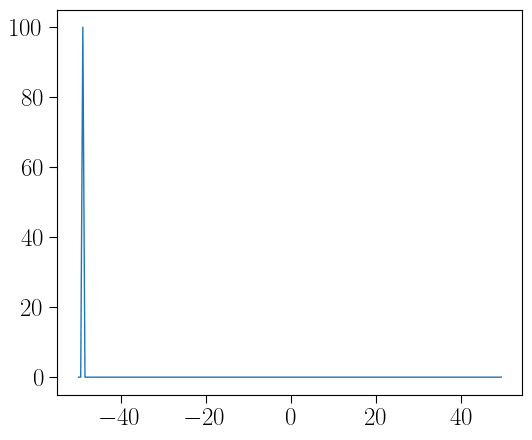

0.5 7.053367989832942


In [5]:
fig1 = plt.figure(figsize=(6,5))
plt.plot(omega, tilde_xi.asnumpy())
plt.show()
print(np.mean(tilde_xi.asnumpy()), np.std(tilde_xi.asnumpy()))

In [6]:
# xi = 2/np.sqrt(N)*F.inverse(tilde_xi)
# plt.plot(time, xi.asnumpy().real)
# print(np.mean(xi.asnumpy().real), np.std(xi.asnumpy()))

Now, let's take our base frequency grid and calculate $\tilde{\xi}(\alpha)^{\ast} \tilde{\xi}(\beta) := \tilde{\xi}(2\omega - 1/2\nu)^{\ast} \tilde{\xi}(-1/2\nu)$, where $\nu$ is a copy of the base $\omega$ grid.

In [7]:
from scipy.interpolate import interp1d
interpolated_tilde_xi = interp1d(omega, tilde_xi.asnumpy(), kind='linear', bounds_error=False, fill_value="extrapolate")
# Note: If the function is trying to be evaluated at e.g. the frequency -625, which is out of bounds, this should naturally be mapped to 250-625 =  - 375 -> 250-375 = -125
# This is done through the 'periodic_frequency_wrap' function.
# So the inputted indices will never lie outside the Nyquist frequency range. But they can lie exactly on the half-open interval of [-f_nyquist, f_nyquist).
# In that case we simply allow for an extrapolation

In [8]:

# Probably don't delete!!

# alpha = 2*omega + 0.5*nu  # if you do here 0.5*nu instead of 0.5*nu[::2], you will get a shape error
# beta = -0.5*nu
#
# print("Where omega star is in alpha: ",np.where(alpha==omega_star))
# print("Where omega star is in beta: ", np.where(beta==omega_star))
#
# alpha_tmp = interpolated_tilde_xi(alpha)
# beta_tmp = interpolated_tilde_xi(beta)
#
# print("Where the peak in xi(alpha) is: ",np.where(alpha_tmp==100))
# print("Where the peak in xi(beta) is: ",np.where(beta_tmp==100))

# stop
alpha = 2*omega[:, None] + 0.5*nu[None, :]  # a grid such that arg1[i,j] = 2*omega_i + 1/2 nu_j. Note that I use omega here instead of nu. That is because if you
# code it without this broadcasting you actually get a shape error.
beta = 0*omega[:, None] - 0.5*nu[None, :]

alpha_masked = alpha.copy()  # keep original if needed
alpha_masked[(alpha < -omega_nyquist) | (alpha > omega_nyquist)] = 0

beta_masked = beta.copy()  # keep original if needed
beta_masked[(beta < -omega_nyquist) | (beta > omega_nyquist)] = 0

# alpha = periodic_frequency_wrap(alpha, omega_nyquist)
# beta = periodic_frequency_wrap(beta, omega_nyquist)

alpha = alpha_masked
beta = beta_masked

# print("Where xi(alpha) is 100 at which frequencies (should ONLY be at -45 or sth? )", alpha[my_future_var])
# ok so like beta is 100 at the 'correct' index? but alpha has multiple entries where it is 100 because it has duplicated omega_star entries? and then probably
# neither of those two match with each other

In [9]:
xi_tilde_alpha = interpolated_tilde_xi(alpha)
xi_tilde_beta = interpolated_tilde_xi(beta)

# print(np.where(xi_tilde_beta==100))
# print(np.where(xi_tilde_alpha==100))
Phi_grid = xi_tilde_alpha.conj() * xi_tilde_beta
print(np.where(Phi_grid==np.max(Phi_grid)))
print(Phi_grid[70, 130]/1e4, np.max(Phi_grid))

(array([2]), array([198]))
0.0 10000.0


Now we try to implement with a known numpy conversion for the FFT the formula

$$S = e^{-2i\omega t} \int \frac{d\nu}{2\pi}e^{-ikx} \Phi(\alpha(\omega, \nu), \beta(\nu))$$

and this is *probably* done by performing a FFT over axis=1. Really need to check if this is true.

In [10]:
E = np.exp(-1j*time[:, None]*nu[None, :])
Prefac = np.exp(-2j*time[:, None]*omega[None, :])

In [11]:
integral = E @ (Phi_grid.T)

In [12]:
scale = 1/(2*np.pi*L) * integral

In [13]:
res = Prefac * scale
print("max: ", np.max(res))

max:  (795.774715459477-3.853162863850568e-15j)


Mean imag part:  4.6465069979411296e-18  vs mean real part:  3.978873577297383


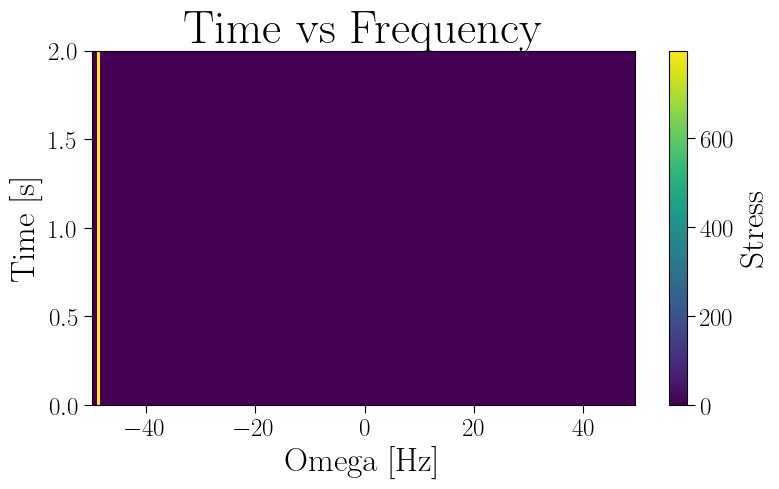

3.978873577297383 56.128919051402896


In [14]:
print("Mean imag part: ", np.mean(res.imag), " vs mean real part: ", np.mean(res.real))
fig2 = plt.figure(figsize=(8,5))
plt.imshow(res.real, origin='lower', aspect='auto',
           extent=[omega[0], omega[-1], time[0], time[-1]],
           cmap='viridis', interpolation='nearest')
plt.colorbar(label='Stress')
plt.xlabel('Omega [Hz]')
plt.ylabel('Time [s]')
plt.title('Time vs Frequency')
plt.tight_layout()
plt.show()

print(np.mean(res.real), np.std(res.real))

We implement in one function

$$S(t,\omega)= e^{-2i\omega t} \int \frac{\mathrm{d}\nu}{2\pi} \Phi(\omega, \nu)e^{-i\nu t},$$

where

$$\Phi(\omega, \nu) = \tilde{\xi}^{\ast}(2\omega+1/2 \nu)\tilde{\xi}(-1/2\nu).$$

Note that $\tilde{\xi}$ is reported at frequencies $\omega$ (there exists bijective map between the $\omega$ and $\tilde{\xi}$ $\texttt{array}$).



In [15]:
import warnings


def xi_field(case, N=None, omegas=None, peak_frequency=None, peak_amplitude=None, base_elevation=None, idx=20, length=None,
             supress_print=False, use_complex=None):

    """

    Returns a Fourier xi field for some cases for which we have an analytic expression of the discretized stress field function
    over for which we can think about what characteristics should be visible in the stress field.

    For the analytical results I assume the discretized version of S used in this notebook.

    case 1:

        xi(ω) = δ_ωω⁎ * a => S(t,ω) = δ_ωω⁎ * a^2 * Δν / (2π) =  δ_ωω⁎ * a^2 *  2Δω/(2π) = δ_ωω⁎ * a^2 * 1/(πL)

        where in the last step we assumed that ν = 2ω was used for the dummy variable in the discretization scheme.

    case 4:
        <xi(ω) xi(ω')> -> δ_ωω' / Δω = δ_ωω' * L

        then, we expect (again assuming Δν = 2Δω) :

            <S(t, ω)> = 1/π ~ 0.318


    :param N:               How many support points in real space
    :param case:            1-4, see cases dict below.
    :param omegas:          The frequency values at which xi should be reported.
    :param peak_frequency:  The position of any peaks in fourier space.
    :param idx:             Extends the peak to a comb from peak_frequncy_idx till peak_frequncy_idx + idx iff case == 3.
    :param peak_amplitude:  The amplitude of any peaks in fourier space.
    :param base_elevation:  Iff case == 2 the base elevation in Fourier space next to the peak.
    :param length:          The real space length used to construct the correct dirac delta discrete representation for the covariance of standard normal variables.
    :param supress_print
    :param use_complex
    :return:
    """

    if omegas is not None:
        N = len(omegas)

    case_names = {
        1: "Spike",
        2: "Spike with constant non-zero elevation",
        3: "Frequency range",
        4: "Normal standard variable"
    }

    if not supress_print:
        print(f"\nConstructing xi field for case {case}: {case_names[case]}\n")

    if case == 1:
        ### --- case 1: Spike
        i_star = np.argmin(np.abs(omegas-peak_frequency))
        omega_star = omega[i_star]

        print("\tOmega star: ", omega_star, " at index ", i_star)

        xi = np.zeros(N)
        xi[i_star] = peak_amplitude
    elif case == 2:
        ### --- case 2: Spike with base elevation
        i_star = np.argmin(np.abs(omegas-peak_frequency))
        omega_star = omega[i_star]

        print("\tOmega star: ", omega_star, " at index ", i_star)

        xi = np.ones(N) * base_elevation
        xi[i_star] = peak_amplitude

    elif case == 3:
        ### --- case 3: Step function over frequency range
        i_star = np.argmin(np.abs(omegas-peak_frequency))
        omega_star = omegas[i_star]

        print("\tPeak elevation at: ", omega_star, " till ", omegas[i_star+idx])

        xi = np.zeros(N)
        xi[i_star:i_star+idx] = peak_amplitude
    elif case == 4:
        ### --- case 4: Step function over frequency range
        xi = sn_complex_xi(N, scale=length, use_complex=use_complex)
    else:
        raise ValueError("Unknown case")

    return xi


def raise_warning(msg):
    warnings.warn(msg, category=UserWarning, stacklevel=2)

def visualize_stress(stress_matrix, omega, time):
    plt.figure(figsize=(8,6))
    plt.imshow(stress_matrix.real, origin='lower', aspect='auto',
               extent=[omega[0], omega[-1], time[0], time[-1]],
               cmap='viridis', interpolation='nearest')
    plt.colorbar(label='Stress')
    plt.xlabel('Omega [Hz]')
    plt.ylabel('Time [s]')
    plt.title('Time vs Frequency')
    plt.tight_layout()
    plt.show()


class CallableArray:
    """
    Maps frequencies to array values, allowing callable-style access.

    Example
    -------
    >>> arr_map = CallableArray(freq, arr)
    >>> arr_map(omega)          # scalar -> scalar
    >>> arr_map([0.1, 0.2])     # array -> array

    Parameters
    ----------
    x : array-like
        Array of unique frequencies (x). Each frequency will act as a key.
    y : array-like
        Array of values corresponding to each frequency. Must have the same length as x.
    bounds_error : bool, default=False
        If True, raises an error when queried with a frequency outside the range
        [-max(|x|), max(|x|)]. If False, such queries return 0.

    Notes
    -----
    - Frequencies must be unique for this mapping to work. If `x` contains duplicates,
      only the last occurrence will be stored, and previous ones overwritten.
    - Out-of-bounds values (outside the largest absolute frequency in `x`) will silently
      return 0 if `bounds_error=False`, so they don’t contribute to sums. Be careful
      if you’re doing operations where the presence of extra 0's matters.
    - If `bounds_error=True` and an array is passed, the error message will report
      the indices of out-of-bounds values.
    - Frequencies between grid points (i.e. not in `x`) always raise an error.
    """
    def __init__(self, x, y, bounds_error=False):
        if len(x) != len(y):
            raise ValueError("x and y must have the same length")
        self._map = dict(zip(x, y))
        self._max_freq = np.max(np.abs(x))
        self._bounds_error = bounds_error

    def __call__(self, omega):
        omega = np.array(omega, copy=False, ndmin=1)  # keeps shape
        out = np.zeros(omega.shape, dtype=np.result_type(*self._map.values()))

        mask_oob = np.abs(omega) > self._max_freq
        if np.any(mask_oob):
            if self._bounds_error:
                bad_idx = np.argwhere(mask_oob)
                raise ValueError(
                    f"Frequencies at indices {bad_idx.tolist()} "
                    f"are out of bounds [-{self._max_freq}, {self._max_freq}]"
                )
            # else: leave zeros there

        it = np.nditer(omega, flags=["multi_index"])
        for w in it:
            if not mask_oob[it.multi_index]:
                try:
                    out[it.multi_index] = self._map[float(w)]
                except KeyError:
                    raise KeyError(f"Frequency {float(w)} not in grid (between points)")

        return out if omega.shape != () else out.item()




def stress(xi:np.array or ift.Field, length, n_pix, standard_order=False, supress_imag_warnings=False):
    r"""
    Implements the discretized version of

        S(t, ω) = e^{-2iωt} ∫ (dν / 2π) Φ(ω, ν) e^{-iνt},

    where

        Φ(ω, ν) = 𝛏̃*(2ω + ½ν) 𝛏̃(-½ν).

    Here 𝛏̃ is reported on a discrete frequency grid ω.
    Since ν is a dummy variable, we discretize it as ν = 2ω, ensuring that all required frequency
    arguments land exactly on the ξ grid.

    Parameters
    ----------
    xi : np.ndarray or ift.Field
        Input field in Fourier space, sampled on the ω grid.
    length : float
        Total physical length of the domain.
    n_pix : int
        Number of pixels used to discretize the domain.
    standard_order : bool, optional
        If True, assumes ξ is in standard FFT ordering, and the output frequencies
        will be ordered accordingly.
    supress_imag_warnings: bool,
        Whether to suppress if the final matrix has a substantial imaginary part.

    Returns
    -------
    S : np.ndarray
        The discretized stress field S(t, ω).
    omega : np.ndarray
        Frequency grid corresponding to ξ.
    t : np.ndarray
        Time grid in [0, length].

    Caveats & Breakpoints
    ---------------------
    - **Boundary enforcement**: The implementation enforces periodicity by hand
      (`xi = np.append(xi, xi[0])`). This assumes ξ[0] and ξ[-1] correspond to the same point
      in Fourier space, which may not hold if the input field is ordered differently.
    - **ν-grid resolution**: We discretize ν with spacing Δν = 2Δω, i.e. twice as coarse as ω.
      This simplifies the alignment but may be suboptimal in terms of accuracy/resolution.
    - **Nyquist frequency**: A delta peak located exactly at the Nyquist frequency is currently
      not represented correctly. Instead, its “twin” at zero frequency is picked up. This should
      be repaired in a future version.
    - **CallableArray behavior**: The evaluation of ξ relies on `CallableArray`, which silently
      sets values outside the Nyquist band to zero. This may cause issues for use cases that
      in which the size of the array is important (the 0's artificially increase N).
    """

    if type(xi) == ift.Field:
        xi = xi.asnumpy()
    L = length
    N = n_pix
    dx = L/N
    x = ift.RGSpace(shape=(N,), distances=dx)
    y = x.get_default_codomain()
    t = np.linspace(0, L, N)
    omega_nyquist = 1/(2*dx)

    omega = mirror_negative_frequencies(y.get_unique_k_lengths(), unique_k_lengths=True, standard_order=standard_order)
    nu = 2*omega.copy()

    symmetric_omega = np.append(omega,omega_nyquist)  # force omega to be symmetric, so xi(-1/2 nu) will not throw an error for Nyquist frequency (max positive value
    # is one step before Nyquist frequency for mirror ordering
    xi = np.append(xi, xi[0])  # enforce condition xi[0] = xi[-1], so the inputted xi at this stage should not fulfill this boundary condition periodicity

    xi = CallableArray(symmetric_omega, xi)
    Phi = xi(2*omega[:, None] + 1/2*nu[None,:]).conj() * xi(0*omega[:, None] - 1/2*nu[None,:])

    E1 = np.exp(-1j*nu[None, :]*t[:, None])
    E2 = np.exp(-2j*omega[None, :]*t[:, None])

    delta_nu = nu[1]-nu[0]  # assuming nu is equidistantly spaced
    integral = E1 @ Phi.T
    S = delta_nu/(2*np.pi) * (E2*integral)

    if not supress_imag_warnings:
        diagnostic = np.abs(np.mean(S.imag))
        if diagnostic < 1e-10:
            print(f"\u2714 Mean imaginary part of stress field is smaller than 1e-10 threshold ({diagnostic}) ")
        else:
            raise_warning(f"Realness threshold was not passed. Mean imaginary part of stress field larger than 1e-10 ({diagnostic}).")

    return S, omega, t




In [16]:
S_mat, omega, time = stress(xi=tilde_xi, length=2, n_pix=200)
print("Max of S_mat: ", np.max(S_mat))

✔ Mean imaginary part of stress field is smaller than 1e-10 threshold (7.393217903081332e-18) 
Max of S_mat:  (1591.5494309189537+1.4638851898916632e-13j)


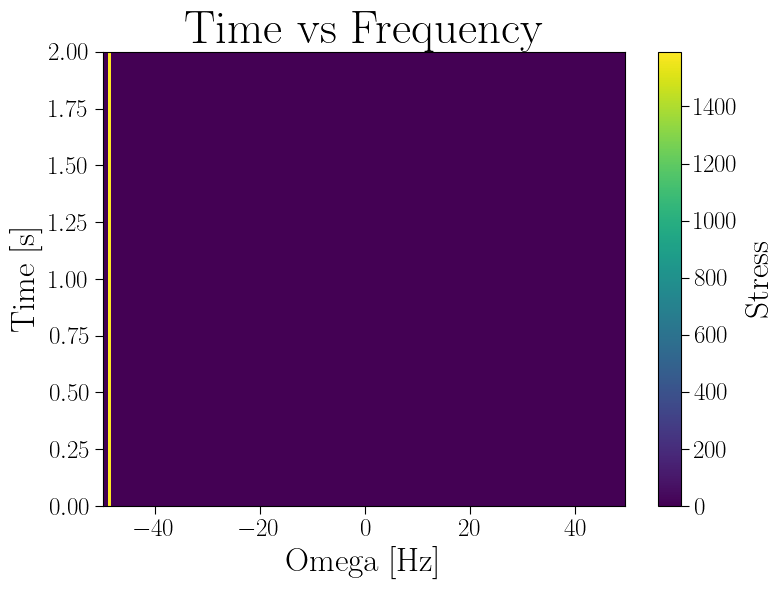

In [17]:
visualize_stress(S_mat, omega, time=time)

Note that for a peak of $a=100$, we analytically expected the max stress of our discretized formula to be

$$\mathrm{max} = a^2 \cdot 1/(πL) = 1e4 /(\pi*2) \approx 1591$$,

which is exactly what we found here. Do we find for our Gaussian standard variable that

$$\langle S(t,\omega) \rangle \approx \frac{1}{\pi}$$

in our discretized version?

In [18]:
omega = None
time = None
S_mat_collection = []
for idx in range(100):
    xi_iter = xi_field(case=4, N=200, length=np.sqrt(2)*np.sqrt(2), supress_print=True)
    if idx == 0:
        S_mat, omega, time = stress(xi=xi_iter, length=2, n_pix=200, supress_imag_warnings=True)
    else:
        S_mat, _, _ = stress(xi=xi_iter, length=2, n_pix=200, supress_imag_warnings=True)
    S_mat_collection.append(S_mat)


np.mean xi:  2.183143006064863
np.mean xi:  1.8860879511746427
np.mean xi:  1.9539712775686149
np.mean xi:  1.916964359895154
np.mean xi:  1.9217937758486365
np.mean xi:  2.1358117356826254
np.mean xi:  2.2753797303731313
np.mean xi:  1.949587459454444
np.mean xi:  2.181605009759277
np.mean xi:  1.9028279591819273
np.mean xi:  2.094146848104632
np.mean xi:  2.021233306988408
np.mean xi:  1.891471812248422
np.mean xi:  2.1911283779110486
np.mean xi:  2.0821544799998826
np.mean xi:  1.8166921402779317
np.mean xi:  2.405366018083779
np.mean xi:  2.150429250627749
np.mean xi:  2.1074808213196174
np.mean xi:  2.1173847814956606
np.mean xi:  2.034826713403739
np.mean xi:  2.094897939795925
np.mean xi:  2.050088361975899
np.mean xi:  1.8725929939100963
np.mean xi:  2.161534421126226
np.mean xi:  1.9694402125200572
np.mean xi:  2.0864472093848394
np.mean xi:  2.1981526095030475
np.mean xi:  2.346145040541111
np.mean xi:  1.8858843323437207
np.mean xi:  2.0946293737071024
np.mean xi:  1.7297472

In [19]:
S_average = np.mean(S_mat_collection, axis=0)

In [20]:
print(np.mean(S_average.real))
print(np.mean(S_average.imag))

0.3181478260924563
-0.00026502954655371853


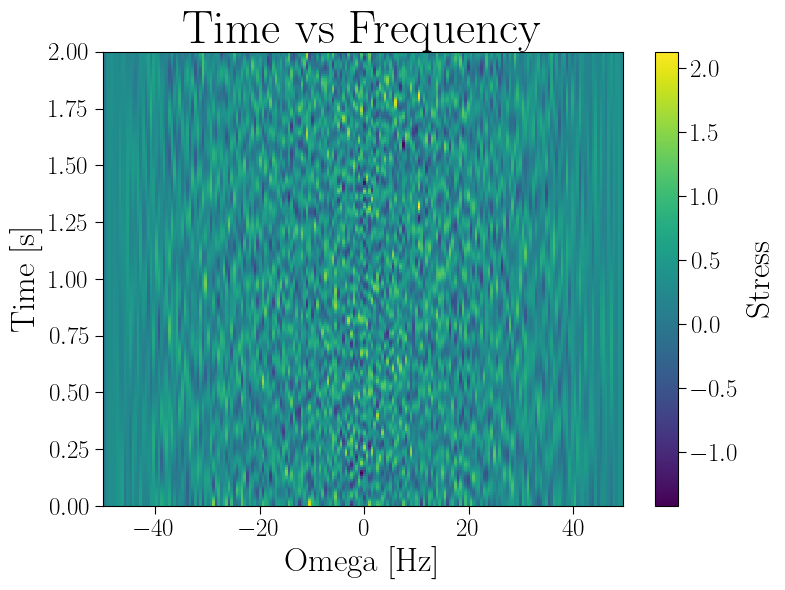

In [21]:
visualize_stress(S_average, omega, time=time)

In [22]:
xi_iter = sn_complex_xi(200, scale=np.sqrt(2), use_complex=False)
print("Mean |xi|^2:", np.mean(np.abs(xi_iter)**2))


Mean |xi|^2: 2.057453354917694


Therefore, I am satisfied with what I have done. My guess for the fact that the imaginary fraction is quite substantial (approx 1/1000 of real part) is that this is numerical noise, in particular from choosing the nu grid twice as coarse as the omega grid.

It maybe that if one uses np.trapz or simpson to do the integration or even an interpolator, the imaginary part falls off. This could even be a nice plot if one looks at how the imaginary part interpreted as error goes down for increasing support points in some integrator.

It may be that if we know try to do the numerical implementation using an FFT directly, that we don't need to choose a coarser grid and the imaginary part again goes to small values.